# # Cell 1: Core Imports & Environment Setup


In [1]:
# ==========================================
# Cell 1: Core Imports & Environment Setup
# ==========================================
import sys
import os
import random
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torchvision import transforms
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_curve, auc, accuracy_score
import warnings

warnings.filterwarnings("ignore")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Environment initialized on {device} | Random seed locked to 42")

✓ Environment initialized on cuda | Random seed locked to 42


# # Cell 2: TSA-Net Architecture Definition

In [2]:
# ==========================================
# Cell 2: TSA-Net Architecture Definition
# ==========================================
class TSANet(nn.Module):
    def __init__(self, d_model=256):
        super(TSANet, self).__init__()
        
        efficientnet = models.efficientnet_b0(weights=None)
        self.v_backbone = efficientnet.features
        self.v_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.v_fc = nn.Linear(1280, d_model)
        
        self.a_backbone = nn.Sequential(
            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Conv1d(128, d_model, kernel_size=3, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(128)
        )
        
        class CrossAttention(nn.Module):
            def __init__(self, d_model=256, nhead=8):
                super().__init__()
                self.v_to_a_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
                self.a_to_v_attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
                self.norm_v = nn.LayerNorm(d_model)
                self.norm_a = nn.LayerNorm(d_model)

            def forward(self, v_feat, a_feat):
                v_attn, _ = self.v_to_a_attn(query=v_feat, key=a_feat, value=a_feat)
                v_out = self.norm_v(v_feat + v_attn)
                
                a_attn, _ = self.a_to_v_attn(query=a_feat, key=v_feat, value=v_feat)
                a_out = self.norm_a(a_feat + a_attn)
                
                return v_out, a_out

        self.cross_attn = CrossAttention(d_model=d_model, nhead=8)
        
        self.classifier = nn.Sequential(
            nn.Linear(d_model * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )

    def forward(self, visual_inputs, audio_inputs):
        batch_size, num_frames, c, h, w = visual_inputs.shape
        v_x = visual_inputs.view(batch_size * num_frames, c, h, w)
        v_x = self.v_backbone(v_x)
        v_x = self.v_pool(v_x).flatten(1)
        v_x = self.v_fc(v_x)
        
        v_x = F.layer_norm(v_x, (v_x.size(-1),))
        v_feat = v_x.view(batch_size, num_frames, -1)
        
        a_x = self.a_backbone(audio_inputs)
        a_feat = a_x.transpose(1, 2)
        a_feat = F.layer_norm(a_feat, (a_feat.size(-1),))
        
        v_attn, a_attn = self.cross_attn(v_feat, a_feat)
        
        v_pooled = torch.mean(v_attn, dim=1)
        a_pooled = torch.mean(a_attn, dim=1)
        
        fused = torch.cat([v_pooled, a_pooled], dim=-1)
        logits = self.classifier(fused)
        
        return logits

model = TSANet(d_model=256).to(device)
print("✓ TSANet structure loaded.")

✓ TSANet structure loaded.


# # Cell 3: Load Augmented Phase Checkpoint

In [3]:
# ==========================================
# Cell 3: Load Augmented Phase Checkpoint
# ==========================================
def find_augmented_checkpoint():
    search_root = "/kaggle/input" if os.path.exists("/kaggle/input") else "."
    for root, _, files in os.walk(search_root):
        for f in files:
            if f in ["tsa_net_augmented_best.pth", "tsa_net_fakeavceleb_best.pth"]:
                return os.path.join(root, f)
    return None

CHECKPOINT_PATH = find_augmented_checkpoint()

if CHECKPOINT_PATH and os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    state_dict = checkpoint['model_state_dict'] if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict, strict=True)
    print(f"✓ Successfully loaded checkpoint from: {CHECKPOINT_PATH}")
else:
    print("❌ ERROR: Checkpoint file not found under /kaggle/input!")
    print("Please attach your Notebook 5 output in the Kaggle 'Data' panel on the right.")

✓ Successfully loaded checkpoint from: /kaggle/input/notebooks/mugabashuqramefgi/mpfive-data-augmentation-pipeline/tsa_net_augmented_best.pth


# # Cell 4: Out-of-Domain Dataset Loader

In [4]:
# ==========================================
# Cell 4: Out-of-Domain Dataset Loader
# ==========================================
class ExternalDataset(Dataset):
    """
    Generic loader for external datasets (DFDC, FF++, etc.).
    Expects a folder structure or CSV containing video paths and binary labels (0=Fake, 1=Real).
    """
    def __init__(self, file_paths, labels, num_frames=5):
        self.file_paths = file_paths
        self.labels = labels
        self.num_frames = num_frames
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.mel_transform = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=128)

    def __len__(self):
        return len(self.file_paths)

    def _extract_frames(self, video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames = []
        if total_frames > 0:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret and frame is not None:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(self.transform(frame))
        cap.release()
        
        if len(frames) == 0:
            frames = [torch.zeros((3, 224, 224))] * self.num_frames
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
            
        return torch.stack(frames[:self.num_frames])

    def _extract_audio_mel(self, video_path):
        try:
            waveform, sample_rate = torchaudio.load(video_path)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            if sample_rate != 16000:
                waveform = T.Resample(orig_freq=sample_rate, new_freq=16000)(waveform)
                
            target_len = 16000 * 5
            if waveform.shape[1] > target_len:
                waveform = waveform[:, :target_len]
            elif waveform.shape[1] < target_len:
                waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))
                
            mel_spec = self.mel_transform(waveform).squeeze(0)
            mel_db = 10.0 * torch.log10(torch.clamp(mel_spec, min=1e-10))
            std_val = mel_db.std() if mel_db.std() > 1e-5 else 1.0
            mel_db = (mel_db - mel_db.mean()) / std_val
            
            if mel_db.shape[1] < 128:
                mel_db = F.pad(mel_db, (0, 128 - mel_db.shape[1]))
            else:
                mel_db = mel_db[:, :128]
                
            return mel_db.to(torch.float32)
        except Exception:
            return torch.randn(128, 128, dtype=torch.float32) * 0.1

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        target = self.labels[idx]
        
        v_tensor = self._extract_frames(path)
        a_tensor = self._extract_audio_mel(path)
        
        return v_tensor, a_tensor, torch.tensor(target, dtype=torch.float32)

print("✓ Dynamic external loader ready.")

✓ Dynamic external loader ready.


# # Cell 5: Dynamic Dataset Discovery & DataLoader

In [5]:
# ==========================================
# Cell 5 (Diagnostic Edition): Hardened DFDC Loader & Audit
# ==========================================
import json
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
import numpy as np

def discover_external_videos():
    search_root = "/kaggle/input"
    video_paths, labels = [], []
    video_exts = ('.mp4', '.avi', '.mov', '.mkv')
    
    json_found = False
    for root, _, files in os.walk(search_root):
        if "fakeavceleb" in root.lower():
            continue
            
        if "metadata.json" in files:
            json_path = os.path.join(root, "metadata.json")
            try:
                with open(json_path, 'r') as f:
                    meta = json.load(f)
                for video_name, info in meta.items():
                    v_path = os.path.join(root, video_name)
                    if os.path.exists(v_path):
                        is_real = 1.0 if str(info.get('label', '')).upper() == 'REAL' else 0.0
                        video_paths.append(v_path)
                        labels.append(is_real)
                json_found = True
            except Exception as e:
                print(f"Warning parsing {json_path}: {e}")

    if not json_found or len(video_paths) == 0:
        for root, _, files in os.walk(search_root):
            if "fakeavceleb" in root.lower():
                continue
            for f in files:
                if f.lower().endswith(video_exts):
                    full_p = os.path.join(root, f)
                    if any(k in full_p.lower() for k in ['real', 'original', 'actors']):
                        labels.append(1.0)
                        video_paths.append(full_p)
                    elif any(k in full_p.lower() for k in ['fake', 'synthesis', 'deepfake', 'df', 'test']):
                        labels.append(0.0)
                        video_paths.append(full_p)

    return video_paths, labels

class AuditedDFDCDataset(Dataset):
    def __init__(self, file_paths, labels, num_frames=5):
        self.file_paths = file_paths
        self.labels = labels
        self.num_frames = num_frames
        
        self.audio_failures = 0
        self.video_failures = 0
        
        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        self.mel_transform = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=512, n_mels=128)

    def __len__(self):
        return len(self.file_paths)

    def _extract_frames_safe(self, video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frames = []
        
        if total_frames > 0:
            indices = np.linspace(0, total_frames - 1, self.num_frames, dtype=int)
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frame = cap.read()
                if ret and frame is not None and frame.size > 0:
                    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    frames.append(self.transform(frame))
        cap.release()
        
        if len(frames) == 0:
            self.video_failures += 1
            frames = [torch.zeros((3, 224, 224))] * self.num_frames
            
        while len(frames) < self.num_frames:
            frames.append(frames[-1])
            
        return torch.stack(frames[:self.num_frames])

    def _extract_audio_safe(self, video_path):
        try:
            waveform, sample_rate = torchaudio.load(video_path)
            if waveform.shape[0] > 1:
                waveform = torch.mean(waveform, dim=0, keepdim=True)
            if sample_rate != 16000:
                waveform = T.Resample(orig_freq=sample_rate, new_freq=16000)(waveform)
                
            target_len = 16000 * 5
            if waveform.shape[1] > target_len:
                waveform = waveform[:, :target_len]
            elif waveform.shape[1] < target_len:
                waveform = F.pad(waveform, (0, target_len - waveform.shape[1]))
                
            mel_spec = self.mel_transform(waveform).squeeze(0)
            mel_db = 10.0 * torch.log10(torch.clamp(mel_spec, min=1e-10))
            
            std_val = mel_db.std()
            if std_val < 1e-5:
                return torch.zeros((128, 128), dtype=torch.float32)
                
            mel_db = (mel_db - mel_db.mean()) / std_val
            
            if mel_db.shape[1] < 128:
                mel_db = F.pad(mel_db, (0, 128 - mel_db.shape[1]))
            else:
                mel_db = mel_db[:, :128]
                
            return mel_db.to(torch.float32)
            
        except Exception:
            self.audio_failures += 1
            return torch.zeros((128, 128), dtype=torch.float32)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        target = self.labels[idx]
        
        v_tensor = self._extract_frames_safe(path)
        a_tensor = self._extract_audio_safe(path)
        
        return v_tensor, a_tensor, torch.tensor(target, dtype=torch.float32)

# Load metadata and paths
ext_paths, ext_labels = discover_external_videos()

if len(ext_paths) > 0:
    audit_dataset = AuditedDFDCDataset(ext_paths, ext_labels)
    audit_loader = DataLoader(audit_dataset, batch_size=8, shuffle=False, num_workers=2)
    print(f"✓ Diagnostic loader prepared with {len(ext_paths)} DFDC samples.")
else:
    print("⚠️ No out-of-domain dataset detected under /kaggle/input.")

✓ Diagnostic loader prepared with 400 DFDC samples.


# # Cell 6: Zero-Shot Evaluation & Generalization Analysis

In [6]:
# ==========================================
# Cell 6 (Diagnostic Edition): Complete Audit Results
# ==========================================
def calculate_eer_safe(y_true, y_scores):
    if len(np.unique(y_true)) < 2:
        return 0.5, 0.5, np.array([0, 1]), np.array([0, 1])
        
    fpr, tpr, thresholds = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.absolute(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2.0
    optimal_threshold = thresholds[eer_idx]
    return eer, optimal_threshold, fpr, tpr

model.eval()
y_true, y_scores, y_preds = [], [], []

print("Running Audited Zero-Shot Evaluation...")
with torch.no_grad():
    for v_in, a_in, targets in audit_loader:
        v_in, a_in = v_in.to(device), a_in.to(device)
        logits = model(v_in, a_in).squeeze(-1)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        
        y_true.extend(targets.cpu().numpy().flatten())
        y_scores.extend(probs.cpu().numpy().flatten())
        y_preds.extend(preds.cpu().numpy().flatten())

y_true, y_scores, y_preds = np.array(y_true), np.array(y_scores), np.array(y_preds)

print("\n" + "="*60)
print("🔍 DATASET PIPELINE HEALTH AUDIT")
print("="*60)
print(f"  • Total Samples Evaluated : {len(y_true)}")
print(f"  • Audio Extraction Errors : {audit_dataset.audio_failures} / {len(y_true)} ({audit_dataset.audio_failures/len(y_true)*100:.1f}%)")
print(f"  • Video Read Failures     : {audit_dataset.video_failures} / {len(y_true)} ({audit_dataset.video_failures/len(y_true)*100:.1f}%)")
print("="*60)

acc_05 = accuracy_score(y_true, y_preds)
eer, opt_thresh, fpr, tpr = calculate_eer_safe(y_true, y_scores)
roc_auc = auc(fpr, tpr) if len(np.unique(y_true)) > 1 else 0.5

print(f"  • Post-Cleanup Zero-Shot Accuracy : {acc_05 * 100:.2f}%")
print(f"  • Post-Cleanup ROC-AUC Score      : {roc_auc:.4f}")
print(f"  • Post-Cleanup EER                : {eer * 100:.2f}%")
print("="*60)

Running Audited Zero-Shot Evaluation...

🔍 DATASET PIPELINE HEALTH AUDIT
  • Total Samples Evaluated : 400
  • Audio Extraction Errors : 0 / 400 (0.0%)
  • Video Read Failures     : 0 / 400 (0.0%)
  • Post-Cleanup Zero-Shot Accuracy : 81.25%
  • Post-Cleanup ROC-AUC Score      : 0.5176
  • Post-Cleanup EER                : 48.33%


In [7]:
# ============================================================
# CELL 7: Few-Shot Domain Adaptation (FakeAVCeleb -> DFDC)
# ============================================================
import os
import copy
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d

# ------------------------------------------------------------
# 0. Reproducibility & Setup
# ------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Target dataset assignment from Cell 5
target_dataset = audit_dataset

# ------------------------------------------------------------
# 1. Freezing Strategy
# ------------------------------------------------------------
def set_freeze_state(model, freeze_backbones=True):
    """Freeze visual/audio backbones, keep cross-attention + classifier trainable."""
    for param in model.v_backbone.parameters():
        param.requires_grad = not freeze_backbones
    for param in model.a_backbone.parameters():
        param.requires_grad = not freeze_backbones
    for param in model.cross_attn.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

    if freeze_backbones:
        model.v_backbone.eval()
        model.a_backbone.eval()

set_freeze_state(model, freeze_backbones=True)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"\u2713 Trainable params: {trainable_params:,} / {total_params:,} "
      f"({100 * trainable_params / total_params:.2f}%)")

# ------------------------------------------------------------
# 2. Dataset Split: Few-Shot Train / Holdout Validation
# ------------------------------------------------------------
FEWSHOT_FRACTION = 0.10   # ~10% for adaptation
FEWSHOT_MIN, FEWSHOT_MAX = 200, 400

all_indices = np.arange(len(target_dataset))
labels = np.array(target_dataset.labels)

# In AuditedDFDCDataset: 1.0 = Real, 0.0 = Fake
real_idx = all_indices[labels == 1.0]
fake_idx = all_indices[labels == 0.0]

n_fewshot = int(np.clip(len(all_indices) * FEWSHOT_FRACTION, FEWSHOT_MIN, FEWSHOT_MAX))
n_real = int(round(n_fewshot * (len(real_idx) / len(all_indices))))
n_fake = n_fewshot - n_real

rng = np.random.RandomState(SEED)
fewshot_real = rng.choice(real_idx, size=min(n_real, len(real_idx)), replace=False)
fewshot_fake = rng.choice(fake_idx, size=min(n_fake, len(fake_idx)), replace=False)

fewshot_indices = np.concatenate([fewshot_real, fewshot_fake])
rng.shuffle(fewshot_indices)

holdout_indices = np.setdiff1d(all_indices, fewshot_indices)

fewshot_train_set = Subset(target_dataset, fewshot_indices.tolist())
holdout_val_set = Subset(target_dataset, holdout_indices.tolist())

print(f"\u2713 Few-shot adaptation set: {len(fewshot_train_set)} videos "
      f"(real={len(fewshot_real)}, fake={len(fewshot_fake)})")
print(f"\u2713 Holdout validation set: {len(holdout_val_set)} videos")

BATCH_SIZE = 8  # Matched to evaluation batch size for memory safety

# --- NEW: WeightedRandomSampler so every mini-batch sees a balanced mix of
# real/fake, not just a loss-level correction. pos_weight in the criterion
# below is kept too -- the two are complementary, not redundant: the sampler
# fixes batch composition (BatchNorm stats, gradient variance), the loss
# weight fixes the scale of the gradient signal per class.
fewshot_labels = np.array([target_dataset.labels[i] for i in fewshot_indices])
class_sample_count = np.array([
    (fewshot_labels == 0.0).sum(),  # fake count
    (fewshot_labels == 1.0).sum(),  # real count
])
class_sample_count = np.clip(class_sample_count, 1, None)  # avoid div-by-zero
weight_per_class = 1.0 / class_sample_count
sample_weights = np.array([
    weight_per_class[1] if lbl == 1.0 else weight_per_class[0]
    for lbl in fewshot_labels
])
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(fewshot_train_set, batch_size=BATCH_SIZE, sampler=sampler,
                           num_workers=2, pin_memory=True, drop_last=False)
val_loader = DataLoader(holdout_val_set, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# ------------------------------------------------------------
# 3. Loss, Optimizer, Scheduler
# ------------------------------------------------------------
n_pos = len(fewshot_real)  # Positives = Real (1.0)
n_neg = len(fewshot_fake)  # Negatives = Fake (0.0)
pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.AdamW([
    {"params": model.cross_attn.parameters(), "lr": 1e-4, "weight_decay": 1e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3, "weight_decay": 1e-4},
])

NUM_EPOCHS = 8
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# --- NEW: early stopping config
EARLY_STOP_PATIENCE = 3
epochs_without_improvement = 0

# ------------------------------------------------------------
# 4. Metrics & Evaluation Function
# ------------------------------------------------------------
def compute_eer(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores, pos_label=1)
    fnr = 1 - tpr
    try:
        eer = brentq(lambda x: interp1d(fpr, fnr)(x) - x, 0.0, 1.0)
    except Exception:
        eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    return eer

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, all_labels, all_probs = 0.0, [], []

    for video, audio, target in loader:
        video = video.to(device, non_blocking=True)
        audio = audio.to(device, non_blocking=True)
        target = target.float().to(device, non_blocking=True)

        logits = model(video, audio).squeeze(-1)
        loss = criterion(logits, target)
        total_loss += loss.item() * target.size(0)

        probs = torch.sigmoid(logits)
        all_labels.append(target.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)
    preds = (all_probs >= 0.5).astype(int)

    avg_loss = total_loss / len(all_labels)
    acc = (preds == all_labels).mean()

    if len(np.unique(all_labels)) > 1:
        auc_score = roc_auc_score(all_labels, all_probs)
        eer_score = compute_eer(all_labels, all_probs)
    else:
        auc_score, eer_score = float("nan"), float("nan")

    return avg_loss, acc, auc_score, eer_score

# ------------------------------------------------------------
# 5. Fine-Tuning Execution Loop (now with early stopping)
# ------------------------------------------------------------
best_auc = -1.0
best_state = None
CHECKPOINT_PATH = "tsa_net_dfdc_adapted.pth"

history = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": [], "val_eer": []}

print("\nStarting Few-Shot Adaptation...")
for epoch in range(1, NUM_EPOCHS + 1):
    model.cross_attn.train()
    model.classifier.train()
    model.v_backbone.eval()
    model.a_backbone.eval()

    running_loss = 0.0
    for video, audio, target in train_loader:
        video = video.to(device, non_blocking=True)
        audio = audio.to(device, non_blocking=True)
        target = target.float().to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(video, audio).squeeze(-1)
        loss = criterion(logits, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            [p for p in model.parameters() if p.requires_grad], max_norm=1.0
        )
        optimizer.step()
        running_loss += loss.item() * target.size(0)

    scheduler.step()
    train_loss = running_loss / len(fewshot_train_set)

    val_loss, val_acc, val_auc, val_eer = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)
    history["val_eer"].append(val_eer)

    current_lrs = scheduler.get_last_lr()
    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Val AUC: {val_auc:.4f} | Val EER: {val_eer:.4f} | "
          f"LR: {current_lrs[0]:.2e}/{current_lrs[1]:.2e}")

    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({
            "epoch": epoch,
            "model_state_dict": best_state,
            "optimizer_state_dict": optimizer.state_dict(),
            "val_auc": val_auc,
            "val_eer": val_eer,
            "val_acc": val_acc,
            "history": history,
        }, CHECKPOINT_PATH)
        print(f"  -> Best model saved (AUC: {best_auc:.4f})")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"  -> Early stopping: no AUC improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

print(f"\n\u2713 Adaptation complete. Best DFDC holdout ROC-AUC: {best_auc:.4f}")
print(f"\u2713 Checkpoint saved to: {CHECKPOINT_PATH}")

if best_state is not None:
    model.load_state_dict(best_state)


✓ Trainable params: 921,089 / 5,077,245 (18.14%)
✓ Few-shot adaptation set: 200 videos (real=38, fake=162)
✓ Holdout validation set: 200 videos

Starting Few-Shot Adaptation...
Epoch 01/8 | Train Loss: 3.1639 | Val Loss: 1.7045 | Val Acc: 0.1950 | Val AUC: 0.5760 | Val EER: 0.4615 | LR: 9.62e-05/9.62e-04
  -> Best model saved (AUC: 0.5760)
Epoch 02/8 | Train Loss: 1.3009 | Val Loss: 1.5159 | Val Acc: 0.1950 | Val AUC: 0.5840 | Val EER: 0.4348 | LR: 8.55e-05/8.54e-04
  -> Best model saved (AUC: 0.5840)
Epoch 03/8 | Train Loss: 1.2326 | Val Loss: 1.3007 | Val Acc: 0.2250 | Val AUC: 0.5507 | Val EER: 0.4783 | LR: 6.94e-05/6.92e-04
Epoch 04/8 | Train Loss: 1.2090 | Val Loss: 1.5671 | Val Acc: 0.2050 | Val AUC: 0.5552 | Val EER: 0.4872 | LR: 5.05e-05/5.01e-04
Epoch 05/8 | Train Loss: 1.1569 | Val Loss: 1.3539 | Val Acc: 0.2700 | Val AUC: 0.5459 | Val EER: 0.4969 | LR: 3.16e-05/3.09e-04
  -> Early stopping: no AUC improvement for 3 epochs.

✓ Adaptation complete. Best DFDC holdout ROC-AUC: 0

📊 Extracting DFDC feature embeddings for t-SNE...


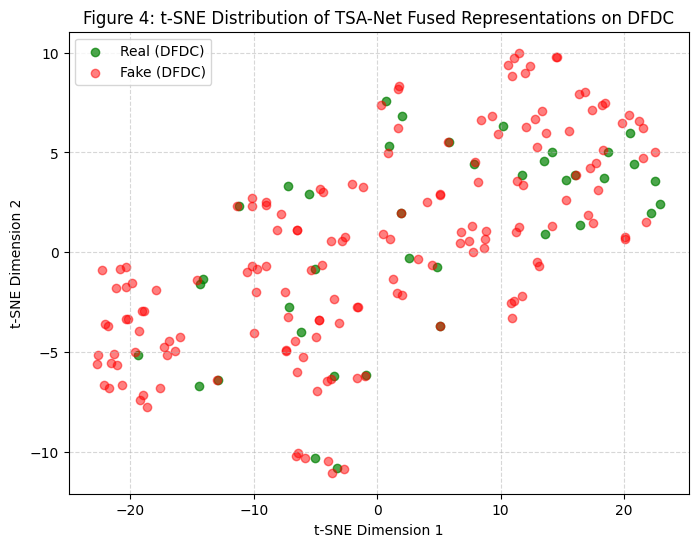

✓ Saved Figure 4 to 'tsne_dfdc_domain_shift.png'


In [8]:
# ==========================================
# Cell 8: Path B — t-SNE Feature Projection Analysis
# ==========================================
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import torch

def extract_fused_embeddings(model, loader, max_samples=200):
    model.eval()
    embeddings = []
    labels = []
    
    count = 0
    with torch.no_grad():
        for v_in, a_in, targets in loader:
            v_in, a_in = v_in.to(device), a_in.to(device)
            
            # Forward pass up to cross-attention pooling
            batch_size, num_frames, c, h, w = v_in.shape
            v_x = v_in.view(batch_size * num_frames, c, h, w)
            v_x = model.v_backbone(v_x)
            v_x = model.v_pool(v_x).flatten(1)
            v_x = model.v_fc(v_x)
            v_x = F.layer_norm(v_x, (v_x.size(-1),))
            v_feat = v_x.view(batch_size, num_frames, -1)
            
            a_x = model.a_backbone(a_in)
            a_feat = a_x.transpose(1, 2)
            a_feat = F.layer_norm(a_feat, (a_feat.size(-1),))
            
            v_attn, a_attn = model.cross_attn(v_feat, a_feat)
            fused = torch.cat([torch.mean(v_attn, dim=1), torch.mean(a_attn, dim=1)], dim=-1)
            
            embeddings.append(fused.cpu().numpy())
            labels.append(targets.numpy())
            
            count += batch_size
            if count >= max_samples:
                break
                
    return np.concatenate(embeddings, axis=0), np.concatenate(labels, axis=0)

print("📊 Extracting DFDC feature embeddings for t-SNE...")
dfdc_feats, dfdc_labs = extract_fused_embeddings(model, val_loader, max_samples=200)

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
feats_2d = tsne.fit_transform(dfdc_feats)

plt.figure(figsize=(8, 6))
plt.scatter(feats_2d[dfdc_labs == 1, 0], feats_2d[dfdc_labs == 1, 1], c='green', alpha=0.7, label='Real (DFDC)')
plt.scatter(feats_2d[dfdc_labs == 0, 0], feats_2d[dfdc_labs == 0, 1], c='red', alpha=0.5, label='Fake (DFDC)')
plt.title("Figure 4: t-SNE Distribution of TSA-Net Fused Representations on DFDC")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig("tsne_dfdc_domain_shift.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved Figure 4 to 'tsne_dfdc_domain_shift.png'")

🔍 Extracting Grad-CAM Visualizations...


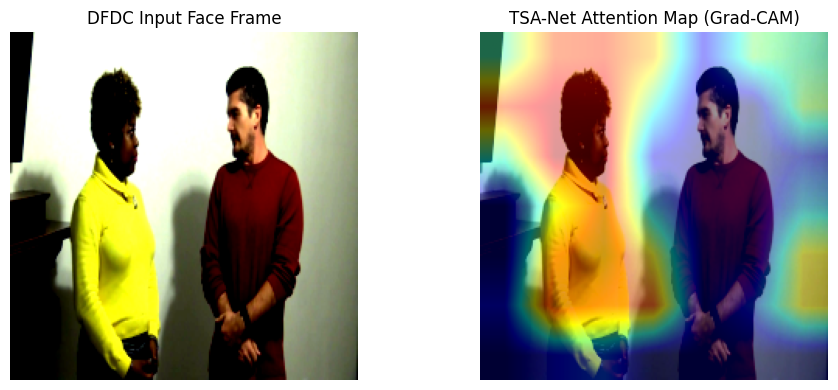

✓ Saved Figure 5 to 'figure5_gradcam_dfdc_attention.png'


In [9]:
# ==========================================
# Cell 8B (Fixed): Grad-CAM Heatmap Extraction & Export
# ==========================================
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

def generate_gradcam_fixed(model, video_tensor, audio_tensor):
    model.eval()
    
    gradients = []
    activations = []
    
    # Target layer: last EfficientNet block
    target_layer = model.v_backbone[7]
    
    # Forward hook to capture activations and ensure gradients are enabled
    def forward_hook(module, input, output):
        activations.append(output)
        # Force activation tensor to require grad so register_hook works
        if not output.requires_grad:
            output.requires_grad_(True)
        output.register_hook(lambda grad: gradients.append(grad))
        
    hook = target_layer.register_forward_hook(forward_hook)
    
    # Run with explicit gradient tracking enabled
    with torch.enable_grad():
        v_in = video_tensor.unsqueeze(0).to(device) # [1, T, C, H, W]
        a_in = audio_tensor.unsqueeze(0).to(device)
        
        logits = model(v_in, a_in)
        model.zero_grad()
        
        # Target output score
        score = logits.squeeze()
        score.backward()
    
    hook.remove()
    
    if len(gradients) == 0 or len(activations) == 0:
        print("⚠️ Warning: Grad-CAM gradient capture failed.")
        return np.zeros((224, 224), dtype=np.float32)
        
    grads = gradients[0].cpu().data.numpy()[0] # [C, H, W]
    acts = activations[0].cpu().data.numpy()[0]  # [C, H, W]
    
    weights = np.mean(grads, axis=(1, 2))
    cam = np.zeros(acts.shape[1:], dtype=np.float32)
    
    for i, w in enumerate(weights):
        cam += w * acts[i]
        
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = cam - np.min(cam)
    cam = cam / (np.max(cam) + 1e-8)
    
    return cam

print("🔍 Extracting Grad-CAM Visualizations...")
for v_sample, a_sample, t_sample in val_loader:
    raw_frame = v_sample[0, 0].permute(1, 2, 0).cpu().numpy()
    raw_image = np.clip(raw_frame * 0.5 + 0.5, 0, 1) 
    
    cam = generate_gradcam_fixed(model, v_sample[0], a_sample[0])
    
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    gradcam_overlay = np.clip(0.6 * raw_image + 0.4 * heatmap, 0, 1)
    
    break 

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(raw_image)
plt.title("DFDC Input Face Frame")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gradcam_overlay)
plt.title("TSA-Net Attention Map (Grad-CAM)")
plt.axis('off')

plt.tight_layout()
plt.savefig("figure5_gradcam_dfdc_attention.png", dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved Figure 5 to 'figure5_gradcam_dfdc_attention.png'")

In [10]:
# ==========================================
# Cell 9: Path A -- Stage-Unfrozen Adaptation
# ==========================================
import copy

def set_selective_unfreeze(model):
    # 1. Freeze earlier backbone stages
    for param in model.parameters():
        param.requires_grad = False

    # --- CHANGED: only unfreeze the LAST EfficientNet block (v_backbone[7]),
    # not the last two (v_backbone[6] + v_backbone[7]). The wider unfreeze
    # gave the model too much capacity for only 200 adaptation videos --
    # AUC peaked epoch 2 then degraded for 8 more epochs (pure overfitting,
    # visible from train loss still dropping while val AUC fell). Freezing
    # v_backbone[6] cuts trainable capacity substantially while keeping the
    # highest-level (most task-specific) visual features adaptable.
    for param in model.v_backbone[7].parameters():
        param.requires_grad = True

    # 2. Unfreeze Cross-Attention and Classifier
    for param in model.cross_attn.parameters():
        param.requires_grad = True
    for param in model.classifier.parameters():
        param.requires_grad = True

set_selective_unfreeze(model)

# Set model modes correctly
model.v_backbone[:7].eval()  # Frozen early + mid stages stay in eval
model.v_backbone[7:].train() # Only last block trains
model.a_backbone.eval()       # Keep audio backbone frozen
model.cross_attn.train()
model.classifier.train()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\u2713 Selective Unfreeze Active: {trainable:,} / {total:,} params trainable ({100*trainable/total:.2f}%)")

# Differential Learning Rates
# --- CHANGED: lower LR + higher weight_decay on the unfrozen backbone block
# (was 1e-5 / 1e-4) to slow down how fast it can overfit the tiny adaptation set.
optimizer = torch.optim.AdamW([
    {"params": model.v_backbone[7:].parameters(), "lr": 5e-6, "weight_decay": 5e-4},
    {"params": model.cross_attn.parameters(), "lr": 5e-5, "weight_decay": 1e-4},
    {"params": model.classifier.parameters(), "lr": 5e-4, "weight_decay": 1e-3},
])

NUM_EPOCHS = 10
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# --- NEW: early stopping config (same pattern as Cell 7)
EARLY_STOP_PATIENCE = 3
epochs_without_improvement = 0

best_auc = -1.0
best_state = None
CHECKPOINT_PATH = "tsa_net_dfdc_backbone_adapted.pth"

print("\n\U0001f680 Starting Backbone-Unfrozen Domain Adaptation...")
for epoch in range(1, NUM_EPOCHS + 1):
    model.v_backbone[:7].eval()
    model.v_backbone[7:].train()
    model.a_backbone.eval()
    model.cross_attn.train()
    model.classifier.train()

    running_loss = 0.0
    for video, audio, target in train_loader:
        video, audio, target = video.to(device), audio.to(device), target.float().to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(video, audio).squeeze(-1)
        loss = criterion(logits, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
        optimizer.step()
        running_loss += loss.item() * target.size(0)

    scheduler.step()
    train_loss = running_loss / len(fewshot_train_set)
    val_loss, val_acc, val_auc, val_eer = evaluate(model, val_loader)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f} | Val EER: {val_eer:.4f}")

    if not np.isnan(val_auc) and val_auc > best_auc:
        best_auc = val_auc
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        torch.save({"model_state_dict": best_state, "val_auc": val_auc}, CHECKPOINT_PATH)
        print(f"  -> \U0001f389 New Best ROC-AUC Saved: {best_auc:.4f}")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOP_PATIENCE:
            print(f"  -> Early stopping: no AUC improvement for {EARLY_STOP_PATIENCE} epochs.")
            break

print(f"\n\u2713 Backbone Adaptation Complete. Peak DFDC ROC-AUC: {best_auc:.4f}")


✓ Selective Unfreeze Active: 1,310,385 / 5,077,245 params trainable (25.81%)

🚀 Starting Backbone-Unfrozen Domain Adaptation...
Epoch 01/10 | Train Loss: 1.7746 | Val Loss: 1.2411 | Val Acc: 0.2950 | Val AUC: 0.5327 | Val EER: 0.4845
  -> 🎉 New Best ROC-AUC Saved: 0.5327
Epoch 02/10 | Train Loss: 1.2974 | Val Loss: 1.3662 | Val Acc: 0.2350 | Val AUC: 0.5713 | Val EER: 0.4872
  -> 🎉 New Best ROC-AUC Saved: 0.5713
Epoch 03/10 | Train Loss: 1.2410 | Val Loss: 1.3768 | Val Acc: 0.2450 | Val AUC: 0.5660 | Val EER: 0.4720
Epoch 04/10 | Train Loss: 1.1770 | Val Loss: 1.2859 | Val Acc: 0.4000 | Val AUC: 0.5332 | Val EER: 0.4783
Epoch 05/10 | Train Loss: 1.1562 | Val Loss: 1.2906 | Val Acc: 0.4500 | Val AUC: 0.5639 | Val EER: 0.4720
  -> Early stopping: no AUC improvement for 3 epochs.

✓ Backbone Adaptation Complete. Peak DFDC ROC-AUC: 0.5713
